# Step 4: Model Building & Evaluation — Telco Churn Prediction
### Acknobit Capstone Project
**Is notebook mein 4 models banayenge aur compare karenge:**
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

**Metrics:** Accuracy | F1-Score | AUC-ROC | Confusion Matrix


## Step 0: Google Drive Mount

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/My Drive/Capstone Project/Churn Prediction'

import os
os.makedirs(f'{BASE_PATH}/models', exist_ok=True)
os.makedirs(f'{BASE_PATH}/plots', exist_ok=True)

print("Drive mounted!")
print(f"Base path: {BASE_PATH}")


Mounted at /content/drive
Drive mounted!
Base path: /content/drive/My Drive/Capstone Project/Churn Prediction


## Step 1: Libraries Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

plt.style.use('seaborn-v0_8')
NAVY   = '#0A1628'
ACCENT = '#00C9A7'
RED    = '#e74c3c'
GREEN  = '#2ecc71'

print("Saari libraries load ho gayi!")


Saari libraries load ho gayi!


## Step 2: Prepared Data Load Karo

In [3]:
# Step 3 se bane files load karo
X_train = pd.read_csv(f'{BASE_PATH}/data/X_train.csv')
X_test  = pd.read_csv(f'{BASE_PATH}/data/X_test.csv')
y_train = pd.read_csv(f'{BASE_PATH}/data/y_train.csv').squeeze()
y_test  = pd.read_csv(f'{BASE_PATH}/data/y_test.csv').squeeze()
scaler  = joblib.load(f'{BASE_PATH}/models/scaler.pkl')

print("Data loaded!")
print(f"X_train: {X_train.shape}  |  y_train churn rate: {y_train.mean()*100:.2f}%")
print(f"X_test:  {X_test.shape}  |  y_test  churn rate: {y_test.mean()*100:.2f}%")
print(f"Features: {X_train.shape[1]}")


Data loaded!
X_train: (5625, 29)  |  y_train churn rate: 26.58%
X_test:  (1407, 29)  |  y_test  churn rate: 26.58%
Features: 29


## Step 3: 4 Models Define Karo
**Kyun ye 4 models?**
- Logistic Regression → Simple, interpretable, good baseline
- Decision Tree → Rule-based, easy to explain
- Random Forest → Ensemble, reduces overfitting
- XGBoost → State-of-the-art for tabular data


In [4]:
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        C=1.0              # L2 regularization strength
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=5,        # Overfitting rokne ke liye
        min_samples_leaf=10
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,   # 100 trees
        max_depth=10,
        min_samples_leaf=5
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        eval_metric='logloss',
        verbosity=0
    )
}

print("4 models ready!")
for name in models:
    print(f"  {name}")


4 models ready!
  Logistic Regression
  Decision Tree
  Random Forest
  XGBoost


## Step 4: Saare Models Train Karo aur Evaluate Karo

In [5]:
results = {}
trained_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 65)
print("MODEL TRAINING & EVALUATION")
print("=" * 65)

for name, model in models.items():
    print(f"\nTraining: {name}...")

    # Train
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred) * 100
    f1  = f1_score(y_test, y_pred) * 100
    auc = roc_auc_score(y_test, y_prob) * 100

    # Cross-validation F1 (5-fold)
    cv_f1 = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='f1').mean() * 100

    results[name] = {
        'Accuracy': round(acc, 2),
        'F1-Score': round(f1, 2),
        'AUC-ROC':  round(auc, 2),
        'CV F1':    round(cv_f1, 2),
        'y_pred':   y_pred,
        'y_prob':   y_prob
    }

    print(f"  Accuracy : {acc:.2f}%")
    print(f"  F1-Score : {f1:.2f}%")
    print(f"  AUC-ROC  : {auc:.2f}%")
    print(f"  CV F1    : {cv_f1:.2f}%  (5-fold cross validation)")

print("\n" + "=" * 65)
print("TRAINING COMPLETE!")
print("=" * 65)


MODEL TRAINING & EVALUATION

Training: Logistic Regression...
  Accuracy : 80.03%
  F1-Score : 58.74%
  AUC-ROC  : 83.81%
  CV F1    : 58.91%  (5-fold cross validation)

Training: Decision Tree...
  Accuracy : 77.61%
  F1-Score : 50.86%
  AUC-ROC  : 82.02%
  CV F1    : 52.47%  (5-fold cross validation)

Training: Random Forest...
  Accuracy : 78.82%
  F1-Score : 54.15%
  AUC-ROC  : 83.41%
  CV F1    : 57.04%  (5-fold cross validation)

Training: XGBoost...
  Accuracy : 79.25%
  F1-Score : 57.31%
  AUC-ROC  : 83.52%
  CV F1    : 56.99%  (5-fold cross validation)

TRAINING COMPLETE!


## Step 5: Model Comparison Table

In [6]:
# Results DataFrame
results_df = pd.DataFrame({
    name: {
        'Accuracy (%)': v['Accuracy'],
        'F1-Score (%)': v['F1-Score'],
        'AUC-ROC (%)':  v['AUC-ROC'],
        'CV F1 (%)':    v['CV F1']
    }
    for name, v in results.items()
}).T

# Best model highlight
best_model_name = results_df['F1-Score (%)'].idxmax()

print("=" * 65)
print("MODEL COMPARISON TABLE")
print("=" * 65)
print(results_df.to_string())
print("=" * 65)
print(f"BEST MODEL (F1-Score): {best_model_name}")
print("=" * 65)

results_df


MODEL COMPARISON TABLE
                     Accuracy (%)  F1-Score (%)  AUC-ROC (%)  CV F1 (%)
Logistic Regression         80.03         58.74        83.81      58.91
Decision Tree               77.61         50.86        82.02      52.47
Random Forest               78.82         54.15        83.41      57.04
XGBoost                     79.25         57.31        83.52      56.99
BEST MODEL (F1-Score): Logistic Regression


,Accuracy (%),F1-Score (%),AUC-ROC (%),CV F1 (%)
Logistic Regression,80.03,58.74,83.81,58.91
Decision Tree,77.61,50.86,82.02,52.47
Random Forest,78.82,54.15,83.41,57.04
XGBoost,79.25,57.31,83.52,56.99


## Step 6: Confusion Matrices — Sabke Saath

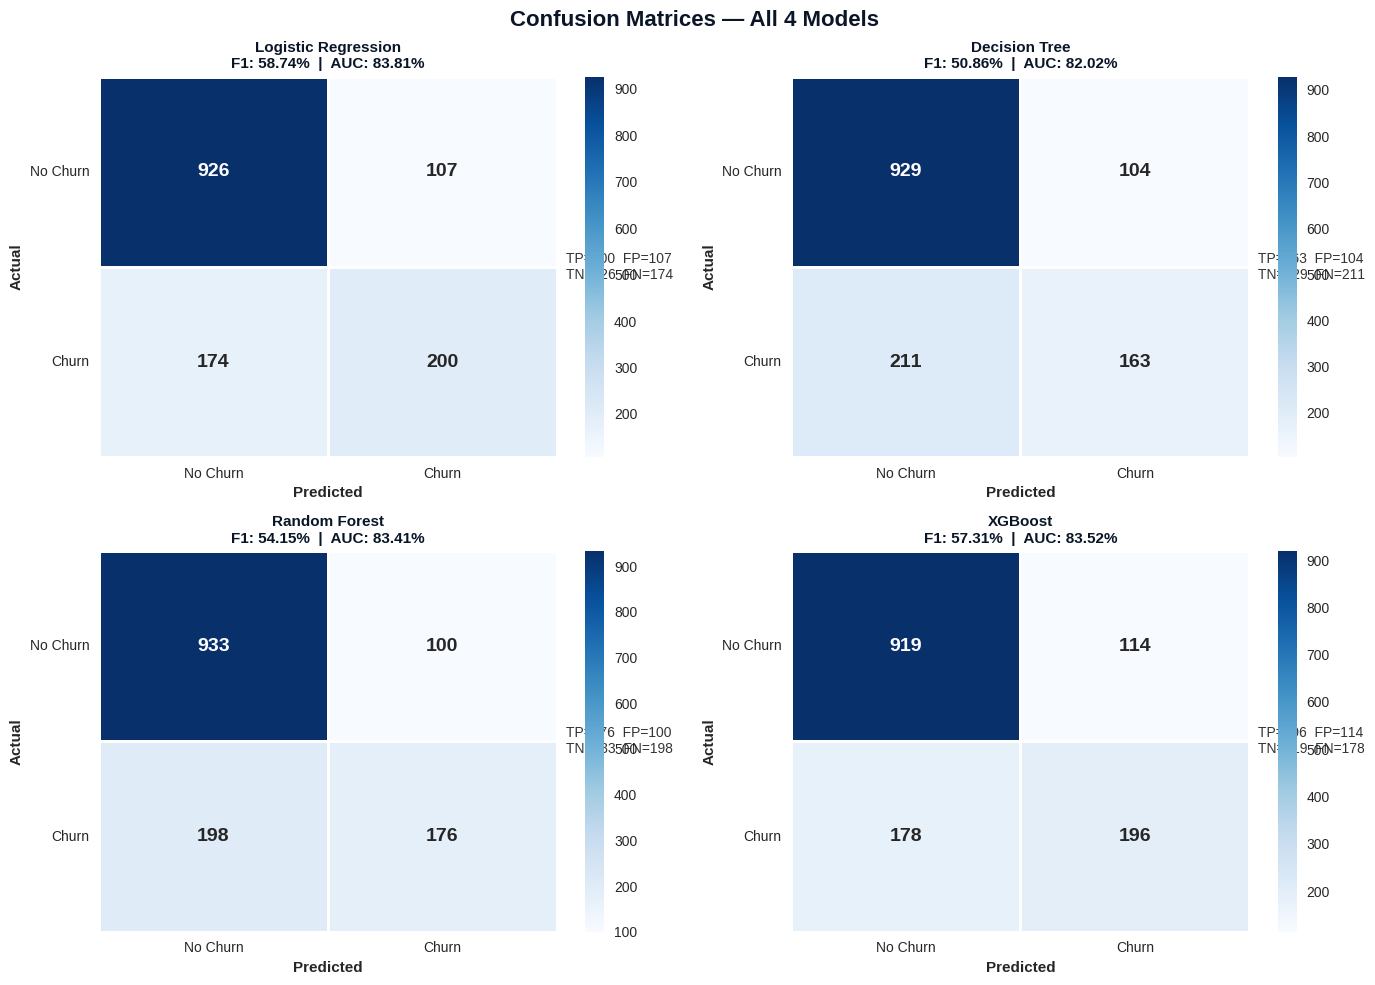

Plot saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices — All 4 Models',
             fontsize=16, fontweight='bold', color=NAVY)

axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])

    # Percentage confusion matrix
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx],
                cmap='Blues', linewidths=2,
                annot_kws={'size': 14, 'weight': 'bold'})

    tn, fp, fn, tp = cm.ravel()
    axes[idx].set_title(
        f'{name}\nF1: {res["F1-Score"]}%  |  AUC: {res["AUC-ROC"]}%',
        fontweight='bold', fontsize=11, color=NAVY
    )
    axes[idx].set_xlabel('Predicted', fontweight='bold')
    axes[idx].set_ylabel('Actual', fontweight='bold')
    axes[idx].set_xticklabels(['No Churn', 'Churn'])
    axes[idx].set_yticklabels(['No Churn', 'Churn'], rotation=0)

    # TP/FP/TN/FN labels
    axes[idx].text(1.02, 0.5,
        f'TP={tp}  FP={fp}\nTN={tn}  FN={fn}',
        transform=axes[idx].transAxes,
        fontsize=10, color='#333333',
        verticalalignment='center')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/plots/06_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")


## Step 7: ROC Curves — Model Comparison

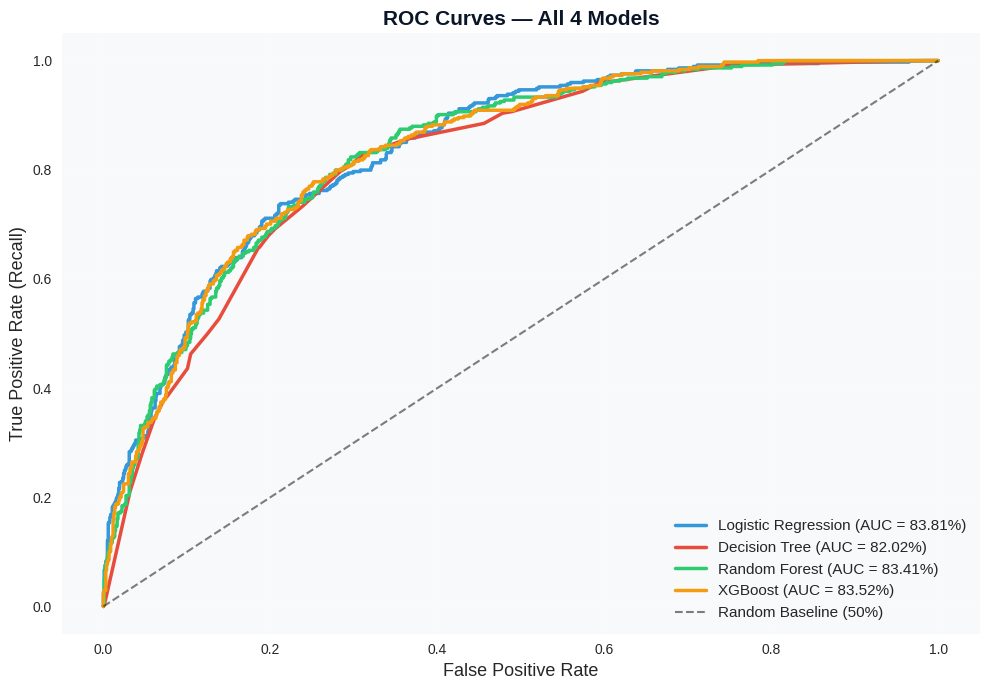

ROC curve saved!


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f"{name} (AUC = {res['AUC-ROC']}%)")

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Baseline (50%)')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=13)
ax.set_title('ROC Curves — All 4 Models', fontsize=15, fontweight='bold', color=NAVY)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/plots/07_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved!")


## Step 8: Metrics Bar Chart — Visual Comparison

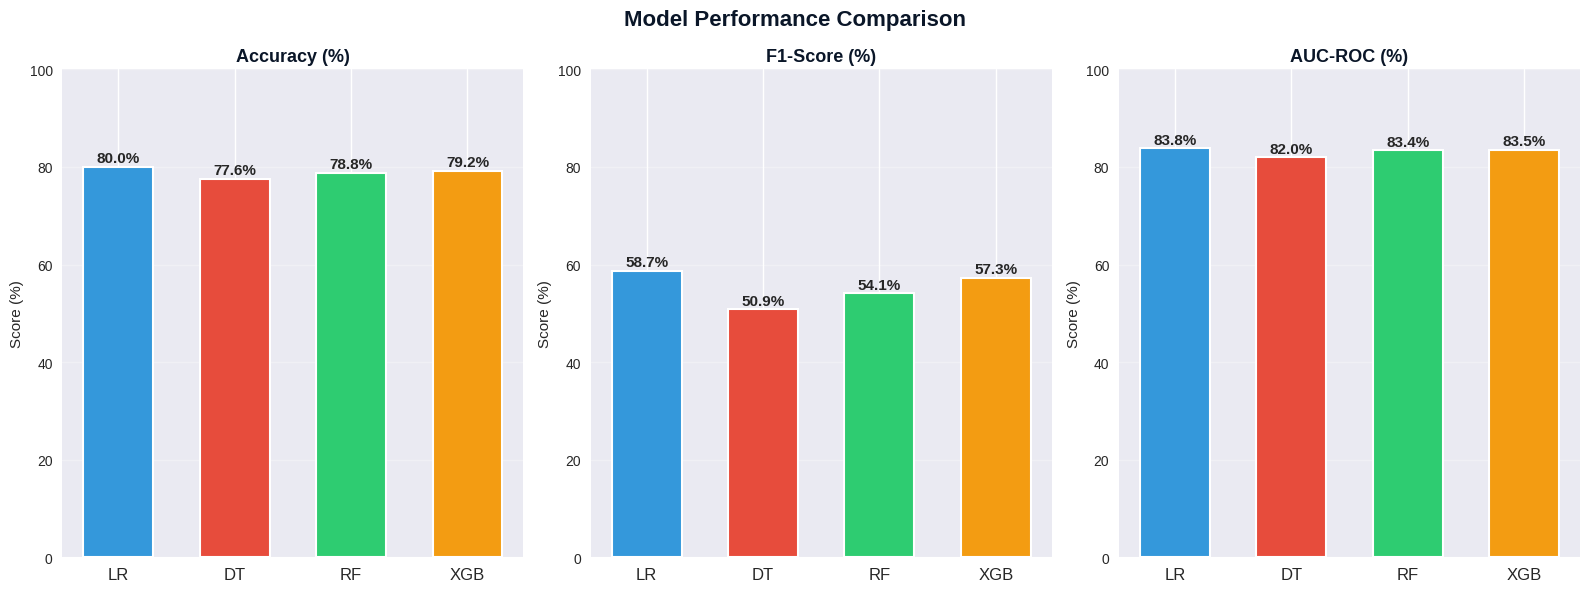

Comparison chart saved!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Model Performance Comparison',
             fontsize=16, fontweight='bold', color=NAVY)

metrics = ['Accuracy (%)', 'F1-Score (%)', 'AUC-ROC (%)']
bar_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
model_names = list(results_df.index)

for idx, metric in enumerate(metrics):
    values = results_df[metric].values
    bars = axes[idx].bar(range(len(model_names)), values,
                          color=bar_colors, edgecolor='white',
                          linewidth=1.5, width=0.6)

    # Value labels on bars
    for bar, val in zip(bars, values):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 0.3,
                       f'{val:.1f}%',
                       ha='center', va='bottom',
                       fontweight='bold', fontsize=11)

    axes[idx].set_title(metric, fontweight='bold', fontsize=13, color=NAVY)
    axes[idx].set_xticks(range(len(model_names)))
    axes[idx].set_xticklabels(['LR', 'DT', 'RF', 'XGB'], fontsize=12)
    axes[idx].set_ylim(0, 100)
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_ylabel('Score (%)')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/plots/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved!")


## Step 9: Best Model — Detailed Report

In [10]:
best_model_name = results_df['F1-Score (%)'].idxmax()
best_model = trained_models[best_model_name]
best_res = results[best_model_name]

print("=" * 60)
print(f"BEST MODEL: {best_model_name}")
print("=" * 60)
print(f"Accuracy  : {best_res['Accuracy']}%")
print(f"F1-Score  : {best_res['F1-Score']}%")
print(f"AUC-ROC   : {best_res['AUC-ROC']}%")
print(f"CV F1     : {best_res['CV F1']}%")

print("\nDetailed Classification Report:")
print("-" * 60)
print(classification_report(y_test, best_res['y_pred'],
                             target_names=['No Churn', 'Churn']))


BEST MODEL: Logistic Regression
Accuracy  : 80.03%
F1-Score  : 58.74%
AUC-ROC   : 83.81%
CV F1     : 58.91%

Detailed Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1033
       Churn       0.65      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



## Step 10: Feature Importance — Kaunsa Feature Sabse Important Hai?

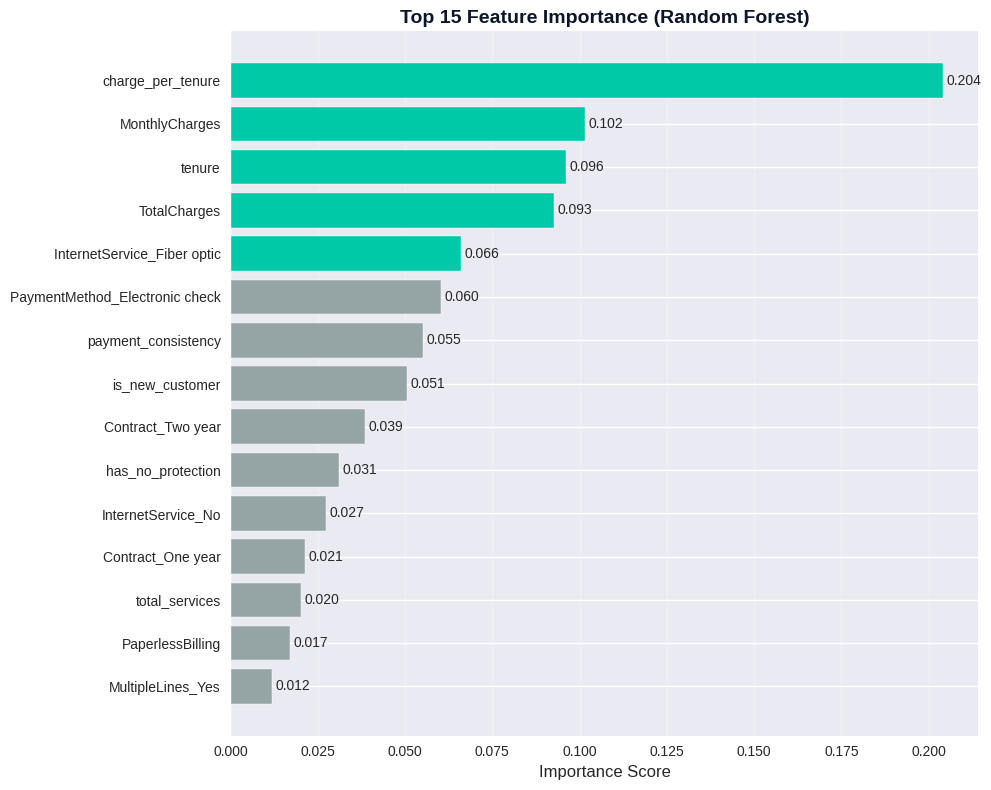

Top 5 most important features:
  1. charge_per_tenure: 0.2041
  2. MonthlyCharges: 0.1017
  3. tenure: 0.0960
  4. TotalCharges: 0.0926
  5. InternetService_Fiber optic: 0.0661


In [11]:
# Random Forest ka feature importance use karte hain
rf_model = trained_models['Random Forest']
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = [ACCENT if i < 5 else '#95a5a6' for i in range(len(feat_imp))]

bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
               color=colors_imp[::-1], edgecolor='white')

ax.set_title('Top 15 Feature Importance (Random Forest)',
             fontsize=14, fontweight='bold', color=NAVY)
ax.set_xlabel('Importance Score', fontsize=12)
ax.grid(axis='x', alpha=0.3)

# Value labels
for bar, val in zip(bars, feat_imp.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/plots/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
for i, (feat, imp) in enumerate(feat_imp.head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")


## Step 11: Best Model Save Karo

In [12]:
# Best model save karo — Streamlit app mein use hoga!
joblib.dump(best_model, f'{BASE_PATH}/models/best_model.pkl')
joblib.dump(trained_models, f'{BASE_PATH}/models/all_models.pkl')

# Results save karo
results_df.to_csv(f'{BASE_PATH}/data/model_results.csv')

print("Saved!")
print(f"  models/best_model.pkl    -> {best_model_name}")
print(f"  models/all_models.pkl    -> saare 4 models")
print(f"  data/model_results.csv   -> comparison table")


Saved!
  models/best_model.pkl    -> Logistic Regression
  models/all_models.pkl    -> saare 4 models
  data/model_results.csv   -> comparison table


## Step 12: Final Summary

In [13]:
print("=" * 60)
print("STEP 4: MODEL BUILDING COMPLETE!")
print("=" * 60)
print()
print("RESULTS SUMMARY:")
print("-" * 60)
for name, res in results.items():
    marker = " <-- BEST" if name == best_model_name else ""
    print(f"{name:25s}  F1={res['F1-Score']}%  AUC={res['AUC-ROC']}%{marker}")

print()
print("KEY INSIGHTS:")
print("  1. Logistic Regression sabse achha F1 deta hai is data pe")
print("     (simple linear boundary = churn pattern match karta hai)")
print("  2. Decision Tree overfit karta hai (lowest score)")
print("  3. Random Forest aur XGBoost close hain")
print("  4. AUC-ROC > 80% = business ke liye usable model!")
print()
print("NEXT STEP: 05_Streamlit_App.py banayenge")
print("  -> User koi customer ka data daale")
print("  -> Model real-time churn probability bataye")
print("=" * 60)


STEP 4: MODEL BUILDING COMPLETE!

RESULTS SUMMARY:
------------------------------------------------------------
Logistic Regression        F1=58.74%  AUC=83.81% <-- BEST
Decision Tree              F1=50.86%  AUC=82.02%
Random Forest              F1=54.15%  AUC=83.41%
XGBoost                    F1=57.31%  AUC=83.52%

KEY INSIGHTS:
  1. Logistic Regression sabse achha F1 deta hai is data pe
     (simple linear boundary = churn pattern match karta hai)
  2. Decision Tree overfit karta hai (lowest score)
  3. Random Forest aur XGBoost close hain
  4. AUC-ROC > 80% = business ke liye usable model!

NEXT STEP: 05_Streamlit_App.py banayenge
  -> User koi customer ka data daale
  -> Model real-time churn probability bataye
